# 逻辑回归（Logistic Regression）

## 数据集说明
- `ex2data1.txt`（2 个特征 + 目标，3 列）
  - 第0列：exam1（第一次考试成绩）
  - 第1列：exam2（第二次考试成绩）
  - 第2列：admitted（是否被录取，1=录取，0=未录取）

---

## 一、数据加载与探索


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 配置 matplotlib 支持中文显示（避免 CJK 字形缺失警告）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False   # 修复负号显示为方块的问题

DATA_FILE = 'ex2data1.txt'   # 数据集文件名

# 读取数据（Jupyter 中工作目录即 .ipynb 所在目录）
df_data = pd.read_csv(DATA_FILE, header=None)

# 查看数据前五行
print("===== 查看数据前五行 =====")
print(df_data.head())

print("===== 查看数据信息 =====")
print(df_data.info())

print("===== 查看数据统计信息 =====")
print(df_data.describe())


===== 查看数据前五行 =====
           0          1  2
0  34.623660  78.024693  0
1  30.286711  43.894998  0
2  35.847409  72.902198  0
3  60.182599  86.308552  1
4  79.032736  75.344376  1
===== 查看数据信息 =====
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       100 non-null    float64
 1   1       100 non-null    float64
 2   2       100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB
None
===== 查看数据统计信息 =====
                0           1           2
count  100.000000  100.000000  100.000000
mean    65.644274   66.221998    0.600000
std     19.458222   18.582783    0.492366
min     30.058822   30.603263    0.000000
25%     50.919511   48.179205    0.000000
50%     67.032988   67.682381    1.000000
75%     80.212529   79.360605    1.000000
max     99.827858   98.869436    1.000000


### 查看数据分布
取出正负样本，根据目标值区分颜色绘制散点图。

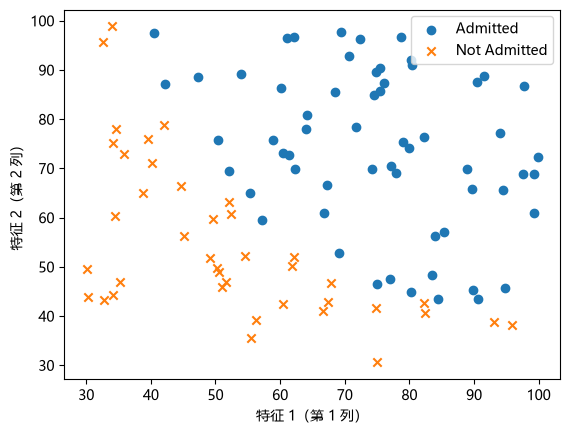

In [2]:
# 取出正负样本
positive = df_data[df_data.iloc[:, -1] == 1]
negative = df_data[df_data.iloc[:, -1] == 0]

# 画出离散分布点，x1为特征1，y2为特征2，根据目标值区分颜色
plt.scatter(positive.iloc[:, 0], positive.iloc[:, 1], marker='o', label='Admitted')
plt.scatter(negative.iloc[:, 0], negative.iloc[:, 1], marker='x', label='Not Admitted')
plt.xlabel('特征 1（第 1 列）')
plt.ylabel('特征 2（第 2 列）')
plt.legend()
plt.show()


---

## 二、特征缩放

- 提取特征列：除最后一列外的所有列（最后一列为目标 y）
- 每个特征分别减去均值、除以标准差（按列 axis=0）
- 添加偏置项（全 1 列），对应 `theta[0]`——即原来的偏置 b，b 已并入 theta 向量


In [3]:
def get_X(df_data):
    # 提取特征列：除最后一列外的所有列（最后一列为目标 y）
    X = df_data.iloc[:, :-1].values
    # 特征缩放：每个特征分别减去均值、除以标准差（按列 axis=0）
    X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    # 添加偏置项（全 1 列），对应 theta[0]——即原来的偏置 b，b 已并入 theta 向量，不再单独使用
    X = np.column_stack((np.ones(len(X)), X))
    return X


def get_y(df_data):
    # 提取目标列（最后一列）
    y = df_data.iloc[:, -1].values
    return y


---

## 三、模型与代价函数

逻辑回归的模型定义为：

$$F(X) = \text{sigmoid}(g(X)), \quad g(X) = X \cdot \theta$$

sigmoid 函数将任意值映射到 (0, 1) 区间：

$$\text{sigmoid}(z) = \frac{1}{1 + e^{-z}}$$

代价函数（衡量预测值与实际值的差异）：

$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y_i \log F(x_i) - (1-y_i) \log(1 - F(x_i)) \right]$$


In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def cost_function(X, y, theta):
    # 计算样本数量
    m = len(y)
    # 计算预测值（np.clip 防止 sigmoid 出现 0/1 导致 log(0)=inf/NaN）
    predictions = np.clip(sigmoid(X.dot(theta)), 1e-10, 1 - 1e-10)
    # 计算代价
    cost = (1 / m) * np.sum(-y * np.log(predictions) - (1 - y) * np.log(1 - predictions))
    return cost


---

## 四、梯度下降算法

梯度下降通过迭代更新模型参数，以逐渐减小代价函数的值：

$$\theta = \theta - \alpha \frac{\partial J(\theta)}{\partial \theta}$$

其中 $\alpha$ 是学习率（learning rate），控制每次迭代的步长。对每个特征 j：

$$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left( F(x_i) - y_i \right) x_{i,j}$$


In [5]:
def gradient_descent(X, y, theta, alpha):
    # 计算样本数量
    m = len(y)
    # 计算预测值
    predictions = sigmoid(X.dot(theta))
    # 对每个特征 j，计算梯度 ∂J(θ)/∂θ_j=(1/m)*sum((F(x_i)-y_i)*x_i_j)
    d_theta = (1 / m) * X.T.dot(predictions - y)
    # 更新参数
    theta = theta - alpha * d_theta
    return theta


def batch_gradient_descent(X, y, theta, alpha=0.01, epoch=1000):
    # 迭代更新参数
    cost_data = [cost_function(X, y, theta)]  # 初始代价（列表，方便 .append()）
    _theta = np.copy(theta)
    for i in range(epoch):
        _theta = gradient_descent(X, y, _theta, alpha)
        cost_data.append(cost_function(X, y, _theta))
    return _theta, cost_data


---

## 五、训练

- X：特征缩放后的特征矩阵（已含偏置列）
- y：目标列（最后一列）
- θ 初始化为 n+1 维零向量（theta[0] 即偏置 b）
- 超参数：alpha=0.01，epoch=1500


In [6]:
X = get_X(df_data)
y = get_y(df_data)

# 初始化参数与超参
theta = np.zeros(X.shape[1])   # X 已含偏置列，θ 为 n+1 维向量（theta[0] 即偏置 b）
alpha = 0.01     # 学习率
epoch = 1500     # 迭代次数

# 运行训练
theta, cost_data = batch_gradient_descent(X, y, theta, alpha, epoch)
print('theta =', np.round(theta, 4))


theta = [0.5812 1.565  1.4077]


---

## 六、决策边界

决策边界是 $\text{sigmoid}(X \cdot \theta) = 0.5$ 的位置，即 $X \cdot \theta = 0$：

$$\theta_0 + \theta_1 x_1 + \theta_2 x_2 = 0$$

- θ 是在**缩放后的特征空间**求得的，绘制边界线时需先缩放、再反变换回**原始特征空间**
- 坐标轴范围限制在数据范围内，避免边界线延伸过远导致散点图被压缩成一团


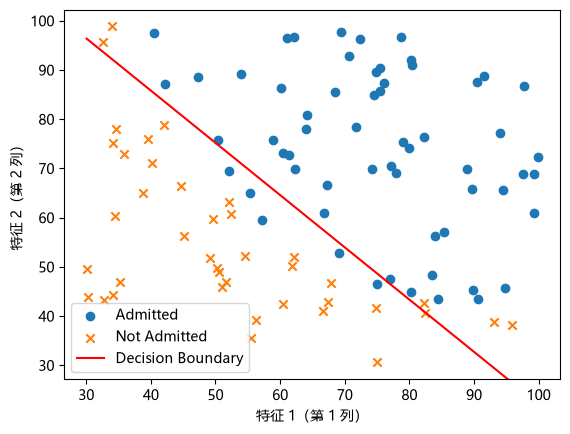

In [7]:
# 先画出所有样本（原始空间），x轴是特征1，y轴是特征2
plt.scatter(positive.iloc[:, 0], positive.iloc[:, 1], marker='o', label='Admitted')
plt.scatter(negative.iloc[:, 0], negative.iloc[:, 1], marker='x', label='Not Admitted')
plt.xlabel('特征 1（第 1 列）')
plt.ylabel('特征 2（第 2 列）')
plt.legend()

# 画出逻辑回归边界  g(X)=X·θ=0，即 θ[0]+θ[1]*x1+θ[2]*x2=0
# θ 是在缩放后的特征空间求得的，需把边界线变换回原始特征空间再绘制
X_raw = df_data.iloc[:, :-1].values
mu = np.mean(X_raw, axis=0)         # 按列均值
sigma = np.std(X_raw, axis=0)       # 按列标准差

# 在原始空间取特征 1 的绘图范围，再缩放到训练时的特征空间
x1_raw = np.linspace(X_raw[:, 0].min(), X_raw[:, 0].max(), 100)
x1_scaled = (x1_raw - mu[0]) / sigma[0]
# 缩放空间内边界：θ[0] + θ[1]*x1_scaled + θ[2]*x2_scaled = 0
x2_scaled = -(theta[1] * x1_scaled + theta[0]) / theta[2]
# 变换回原始空间
x2_raw = x2_scaled * sigma[1] + mu[1]
plt.plot(x1_raw, x2_raw, color='red', label='Decision Boundary')
# 限制坐标轴范围在数据范围内，避免边界线延伸过远导致散点图被压缩成一团
x_margin = 0.05 * (X_raw[:, 0].max() - X_raw[:, 0].min())
y_margin = 0.05 * (X_raw[:, 1].max() - X_raw[:, 1].min())
plt.xlim(X_raw[:, 0].min() - x_margin, X_raw[:, 0].max() + x_margin)
plt.ylim(X_raw[:, 1].min() - y_margin, X_raw[:, 1].max() + y_margin)
plt.legend()
plt.show()


### 收敛曲线
观察代价随迭代次数的下降情况，验证梯度下降是否收敛。

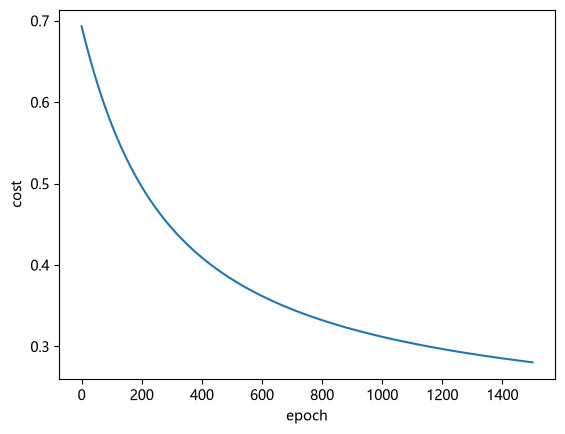

In [8]:
# 收敛曲线：代价随迭代次数逐渐下降
plt.plot(cost_data)
plt.xlabel('epoch')
plt.ylabel('cost')
plt.show()


### 不同学习率对比

学习率 $\alpha$ 控制每次参数更新的步长：步长太小收敛慢，步长太大会震荡甚至发散。
下面用相同的初始化（θ=0）与迭代次数（1500），对比不同学习率的收敛曲线。


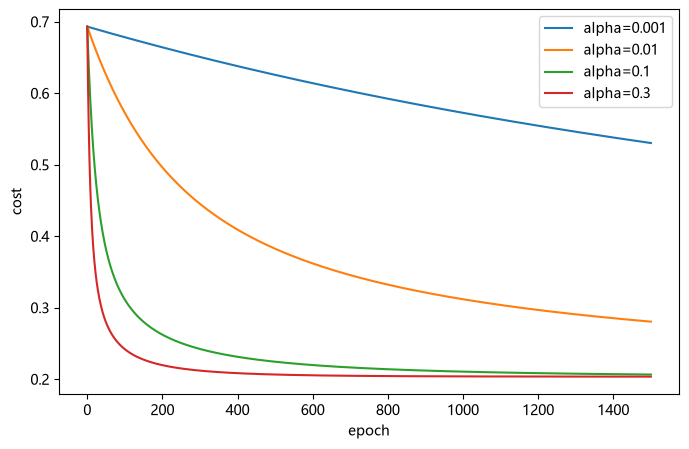

In [9]:
# 对比不同学习率对收敛速度的影响（每次从 θ=0 重新训练）
alphas = [0.001, 0.01, 0.1, 0.3]
plt.figure(figsize=(8, 5))
for a in alphas:
    theta_a, cost_a = batch_gradient_descent(X, y, np.zeros(X.shape[1]), alpha=a, epoch=1500)
    plt.plot(cost_a, label=f'alpha={a}')
plt.xlabel('epoch')
plt.ylabel('cost')
plt.legend()
plt.show()



### 预测
新样本需使用与训练时相同的特征缩放（按列 axis=0，`mu`/`sigma` 已在边界绘制处求得）。

In [10]:
# （可选）预测
new_x = np.array([45, 85])   # 例：exam1=45，exam2=85
new_x_scaled = (new_x - mu) / sigma
new_X = np.concatenate(([1], new_x_scaled))  # 拼接偏置列
pred = sigmoid(new_X.dot(theta))
print(f'预测结果: {pred:.4f}')


预测结果: 0.5847
